In [26]:
from typing import Dict,TypedDict
from langgraph.graph import StateGraph,START,END

In [27]:
class AgentState(TypedDict):
    number1:int
    operation:str
    number2:int
    finalno:int

def adder(state: AgentState)->AgentState:
    state["finalno"]=state["number1"]+state["number2"]
    return state
def subtractor(state:AgentState)->AgentState:
    state["finalno"]=state["number1"]-state["number2"]
    return state
def decider(state:AgentState)->AgentState:
    if state["operation"]=="+":
        return "adder_op"
    elif state["operation"]=="-":
        return "subtractor_op"

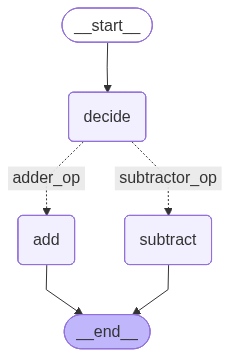

In [28]:
graph=StateGraph(AgentState)

graph.add_node("add",adder)
graph.add_node("subtract",subtractor)
graph.add_node("decide",lambda state:state)
graph.add_edge(START,"decide")
graph.add_conditional_edges(
    "decide",
    decider,
    {
        "adder_op":"add",
        "subtractor_op":"subtract"
    }

)
graph.add_edge("add",END)
graph.add_edge("subtract",END)
app=graph.compile()
graph.compile()

In [29]:
res=app.invoke({"number1":23, "number2":15, "operation":"+"})

In [30]:
res["finalno"]

38